<a href="https://colab.research.google.com/github/bkadyrbay-hash/llm3lab/blob/main/llmlab4KadyrbayB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP — Transformers and Dyck Languages: Error Detection, Correction, and Interpretability

**Botakoz Kadyrbay** | M1 Computational Linguistics

---
*This notebook is the complete lab report. It includes data generation, model implementation, all experiments (Q4–Q15, Q17–Q19), attention analysis, probing classifiers, and a curriculum learning modification (Q18). Theoretical answers (Q1–Q3, Q17–Q19) are written in Markdown cells throughout.*

## 1. Introduction and Background

**Dyck languages** D(k) are the canonical context-free languages: for k ≥ 1, D(k) is the set of all well-balanced strings over k types of bracket pairs. They occupy a central position in formal language theory — every context-free language is a homomorphic image of D(2) ∩ R for some regular language R, making D(2) universal for the class of CFLs. Testing whether a neural model can learn Dyck membership is therefore a principled proxy for testing structural, hierarchical generalisation.

This assignment trains a small BERT-style Transformer encoder to **detect** errors in Dyck strings (binary classification on [CLS]) and **correct** them (sequence labelling per token), then analyses what the model actually learns via attention visualisation and linear probing classifiers. The central question throughout is: *does the Transformer learn a rule for Dyck membership, or a bounded statistical approximation?*

## 2. Theoretical Questions

### Q1 — Chomsky hierarchy and universality of D(2)

Dyck languages are **context-free (Type 2)** in the Chomsky hierarchy. They are not regular (Type 3): recognising balanced brackets requires unbounded memory to track nesting depth, which finite automata cannot provide. The grammar S → ε | SS | a_i S ā_i is context-free but not right-linear.

**Universality of D(2) for CFLs.** The Chomsky–Schützenberger theorem (1963) states that every CFL L can be written as L = h(D(2) ∩ R) where R is a regular language and h is a homomorphism. The argument sketch:
1. Every CFL has a grammar in Chomsky Normal Form. Each binary production A → BC is encoded as an opening bracket; the matching closing bracket appears after the yield of the B-subtree is completed.
2. By choosing one bracket type per non-terminal, every derivation tree maps bijectively to a string in D(2). The regular language R enforces that only valid derivation encodings are selected (e.g. matching non-terminals). The homomorphism h reads off the terminal yield.

This makes D(k) an ideal benchmark: a model that truly masters D(2) has the capacity to recognise any CFL. Failure on D(k) under distribution shift therefore reveals a fundamental limitation in structural generalisation.

---

### Q2 — Real-world examples

**Example 1: Programming language syntax.**
In Python, Java, C, etc., balanced parentheses `()`, brackets `[]`, and braces `{}` form a Dyck language over k=3. Every well-formed expression has matched brackets. The most common real-world mistake is **E3 (type mismatch)**: writing `f(x]` instead of `f(x)`. **E1 (missing closer)** corresponds to an unclosed parenthesis, typically caught at end-of-file by the parser.

**Example 2: Natural language clause nesting.**
In formal syntax (Minimalism, GB), sentences have nested phrase structure: VP inside TP inside CP. Long-distance dependencies (relative clauses, questions) require matching an opener (e.g. a `wh`-phrase) with a closer (a gap). **E4 (premature close)** corresponds to a dependency without an antecedent — e.g. a relative pronoun without a head noun. **E3 (type mismatch)** maps to agreement violations: closing a DP with a VP-type feature.

---

### Q3 (Bonus) — LSTM memory and Transformer OOD limits

An LSTM with hidden dimension h can recognise D(1) = {aⁿāⁿ} with O(1) memory: one counter suffices. For D(k) with k ≥ 2, the stack at depth n can contain any sequence of n bracket types, requiring O(n log k) bits. An LSTM of fixed size h can only represent O(h) independent counters, so it must fail for n > h. Memory requirements grow with nesting depth.

A Transformer with fixed attention width n_heads faces an analogous constraint. In principle it can implement a stack via attention: one head per nesting level tracks the corresponding opener. With n_heads = 4, it can precisely track at most 4 nesting levels. For OOD depth n > n_heads, the model must generalise its computation compositionally — which standard training does not guarantee. This predicts that OOD accuracy degrades as a function of depth rather than length, and that the degradation is related to how far depth exceeds n_heads.

## 3. Imports

In [ ]:
import random, math, copy, itertools
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             r2_score)
from sklearn.linear_model import LinearRegression, LogisticRegression

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


## 4. Data Generation

We use D(2) throughout (bracket pairs `( )` and `[ ]`). The corpus is generated synthetically:

| Split | Distribution | Lengths | Size |
|-------|-------------|---------|------|
| Train | D(2, n≤4), balanced classes | 4–40 tokens | 50,000 |
| Dev | D(2, n≤4), balanced classes | 4–40 tokens | 5,000 |
| In-dist test | D(2, n≤4), balanced classes | 4–40 tokens | 5,000 |
| OOD test | D(2, n∈{5,6,7}) | 40–80 tokens | 5,000 |

Each example is either a correct Dyck string (label 0) or a corrupted version with exactly one error (label 1):
- **E1 — Missing closer**: delete a random closing bracket
- **E2 — Spurious opener**: insert an extra opening bracket  
- **E3 — Type mismatch**: replace a closer with the wrong type (e.g. `( … ]`)
- **E4 — Premature close**: insert a closer before any matching opener exists on the stack

In [ ]:
PAIRS = [('(', ')'), ('[', ']')]

def generate_dyck(length: int, max_depth: int, k: int = 2):
    """Wisniewski's generator — exact copy from the assignment."""
    assert length % 2 == 0
    stack, result, depth = [], [], 0
    remaining = length
    for step in range(length):
        must_close = (len(stack) == remaining)
        can_open   = (depth < max_depth) and (remaining > len(stack) + 1)
        choices = []
        if can_open and not must_close: choices.append('open')
        if stack: choices.append('close')
        if not choices: return None
        match random.choice(choices):
            case 'open':
                pair = random.choice(PAIRS[:k])
                stack.append(pair); result.append(pair[0]); depth += 1
            case 'close':
                pair = stack.pop(); result.append(pair[1]); depth = len(stack)
        remaining -= 1
    return ''.join(result) if not stack else None


def nesting_depth(s):
    """Return max nesting depth of a Dyck string."""
    depth = cur = 0
    for ch in s:
        if ch in '([': cur += 1; depth = max(depth, cur)
        else: cur -= 1
    return depth


def corrupt(s):
    """Apply exactly one random error (E1-E4). Returns (corrupted, error_type)."""
    s = list(s)
    openers  = [i for i,c in enumerate(s) if c in '([']
    closers  = [i for i,c in enumerate(s) if c in ')]']
    CLOSER_MAP = {'(': ')', '[': ']', ')': '(', ']': '['}
    ALT_CLOSE  = {')': ']', ']': ')'}

    ops = []
    if closers: ops.append('E1')
    if openers: ops.append('E2')
    if closers: ops.append('E3')
    ops.append('E4')

    etype = random.choice(ops)

    if etype == 'E1':  # missing closer — delete a random closing bracket
        i = random.choice(closers)
        s.pop(i)

    elif etype == 'E2':  # spurious opener — insert extra opener
        i = random.randint(0, len(s))
        pair = random.choice(PAIRS)
        s.insert(i, pair[0])

    elif etype == 'E3':  # type mismatch — replace closer with wrong type
        i = random.choice(closers)
        s[i] = ALT_CLOSE[s[i]]

    elif etype == 'E4':  # premature close — insert closer before any matching opener
        i = random.randint(0, len(s))
        ch = random.choice([']', ')'])
        s.insert(i, ch)

    return ''.join(s), etype


def make_dataset(n_examples, lengths, max_depths, balanced=True):
    """
    Returns list of (string, label, error_type)
    label 0 = correct, 1 = erroneous
    error_type in {None, 'E1','E2','E3','E4'}
    """
    data = []
    half = n_examples // 2
    # correct strings
    while len(data) < half:
        l = random.choice(lengths)
        d = random.choice(max_depths)
        s = generate_dyck(l, d)
        if s: data.append((s, 0, None))
    # corrupted strings
    while len(data) < n_examples:
        l = random.choice(lengths)
        d = random.choice(max_depths)
        s = generate_dyck(l, d)
        if s:
            c, etype = corrupt(s)
            data.append((c, 1, etype))
    random.shuffle(data)
    return data


LENGTHS_ID  = list(range(4, 42, 2))
DEPTHS_ID   = [1, 2, 3, 4]
LENGTHS_OOD = list(range(40, 82, 2))
DEPTHS_OOD  = [5, 6, 7]

print('Generating datasets...')
train_data = make_dataset(50000, LENGTHS_ID, DEPTHS_ID)
dev_data   = make_dataset(5000,  LENGTHS_ID, DEPTHS_ID)
test_data  = make_dataset(5000,  LENGTHS_ID, DEPTHS_ID)
ood_data   = make_dataset(5000,  LENGTHS_OOD, DEPTHS_OOD)
print(f'Train: {len(train_data)}  Dev: {len(dev_data)}  Test: {len(test_data)}  OOD: {len(ood_data)}')
print('Sample:', train_data[0])

Generating datasets...
Train: 50000  Dev: 5000  Test: 5000  OOD: 5000
Sample: ('[[]][][()][()][[]()][)[]()[]', 1, 'E3')


## 5. Tokenisation

Vocabulary: `[PAD]`, `[CLS]`, `[SEP]`, `(`, `)`, `[`, `]` — 7 tokens total.  
Every sequence is prepended with `[CLS]` and padded to length 82 (`[CLS]` + up to 80 chars + `[SEP]`).

In [ ]:
VOCAB   = ['[PAD]', '[CLS]', '[SEP]', '(', ')', '[', ']']
V2I     = {v: i for i, v in enumerate(VOCAB)}
I2V     = {i: v for v, i in V2I.items()}
PAD_ID  = V2I['[PAD]']
CLS_ID  = V2I['[CLS]']
SEP_ID  = V2I['[SEP]']
MAX_LEN = 82  # [CLS] + up to 80 chars + [SEP]

def tokenise(s, max_len=MAX_LEN):
    ids = [CLS_ID] + [V2I[c] for c in s] + [SEP_ID]
    ids = ids[:max_len]
    pad = max_len - len(ids)
    ids += [PAD_ID] * pad
    mask = [1] * (max_len - pad) + [0] * pad
    return ids, mask

print('Vocab:', V2I)
ids, mask = tokenise('([])')
print('([])->', ids, '\nmask->', mask)

Vocab: {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2, '(': 3, ')': 4, '[': 5, ']': 6}
([])-> [1, 3, 5, 6, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 
mask-> [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 6. Correction Labels (Sequence Labelling Setup — Q5)

Correction is formulated as sequence labelling: each token position receives a label in  
`{OK, DELETE, INSERT_(, INSERT_), INSERT_[, INSERT_], REPLACE_(, REPLACE_), REPLACE_[, REPLACE_]}`.  

`make_correction_labels()` aligns the original and corrupted string and marks the first differing position. This is a **heuristic approximation** — see Q5 interpretation for limitations.

In [ ]:
# Correction label set
CORR_LABELS = ['OK', 'DELETE',
                'INSERT_(', 'INSERT_)', 'INSERT_[', 'INSERT_]',
                'REPLACE_(', 'REPLACE_)', 'REPLACE_[', 'REPLACE_]']
CL2I = {l: i for i, l in enumerate(CORR_LABELS)}
N_CORR = len(CORR_LABELS)

def make_correction_labels(original, corrupted, etype):
    """
    Given the original Dyck string and its corrupted version,
    produce token-level correction labels (after [CLS]).
    This is a heuristic alignment: we mark the first position
    that differs between original and corrupted.
    """
    max_len = MAX_LEN
    # Full sequence including CLS/SEP
    orig_toks  = ['[CLS]'] + list(original)  + ['[SEP]']
    corr_toks  = ['[CLS]'] + list(corrupted) + ['[SEP]']

    labels = [CL2I['OK']] * max_len

    if etype is None:
        return labels  # correct string — all OK

    # Find first differing position
    for i, (o, c) in enumerate(zip(orig_toks, corr_toks)):
        if i >= max_len: break
        if o != c:
            if etype == 'E1':   # closer was deleted — need INSERT
                labels[i] = CL2I.get(f'INSERT_{o}', CL2I['OK'])
            elif etype == 'E2': # opener was inserted — need DELETE
                labels[i] = CL2I['DELETE']
            elif etype == 'E3': # wrong closer — need REPLACE
                labels[i] = CL2I.get(f'REPLACE_{o}', CL2I['OK'])
            elif etype == 'E4': # spurious closer — need DELETE
                labels[i] = CL2I['DELETE']
            break

    return labels

print('Correction labels:', CORR_LABELS)
print('N_CORR:', N_CORR)

Correction labels: ['OK', 'DELETE', 'INSERT_(', 'INSERT_)', 'INSERT_[', 'INSERT_]', 'REPLACE_(', 'REPLACE_)', 'REPLACE_[', 'REPLACE_]']
N_CORR: 10


## 7. PyTorch Datasets

In [ ]:
class DyckDataset(Dataset):
    def __init__(self, data):
        self.samples = []
        for (s, label, etype) in data:
            ids, mask = tokenise(s)
            depth = nesting_depth(s)
            # For correct strings, we need the original to make correction labels
            # For corrupted strings, etype is known but original is not stored
            # We use a dummy correction (all OK) — the correction task uses separate data
            corr_labels = [CL2I['OK']] * MAX_LEN
            ETYPE2ID = {None: -1, 'E1': 1, 'E2': 2, 'E3': 3, 'E4': 4}
            self.samples.append({
                'ids':        torch.tensor(ids, dtype=torch.long),
                'mask':       torch.tensor(mask, dtype=torch.long),
                'label':      torch.tensor(label, dtype=torch.long),
                'etype_id':   torch.tensor(ETYPE2ID.get(etype, -1), dtype=torch.long),
                'etype':      etype if etype else 'none',
                'depth':      depth,
                'string':     s,
                'corr':       torch.tensor(corr_labels, dtype=torch.long),
            })

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


class DyckCorrDataset(Dataset):
    """Dataset for correction task — stores original/corrupted pairs."""
    def __init__(self, n=20000, lengths=None, depths=None):
        lengths = lengths or LENGTHS_ID
        depths  = depths  or DEPTHS_ID
        self.samples = []
        while len(self.samples) < n:
            l = random.choice(lengths)
            d = random.choice(depths)
            orig = generate_dyck(l, d)
            if not orig: continue
            # 50% correct, 50% corrupted
            if random.random() < 0.5:
                s, etype = orig, None
            else:
                s, etype = corrupt(orig)
                orig_for_label = orig
            orig_for_label = orig if etype is None else orig
            ids, mask = tokenise(s)
            corr = make_correction_labels(orig_for_label, s, etype)
            self.samples.append({
                'ids':   torch.tensor(ids,  dtype=torch.long),
                'mask':  torch.tensor(mask, dtype=torch.long),
                'corr':  torch.tensor(corr, dtype=torch.long),
                'label': torch.tensor(0 if etype is None else 1, dtype=torch.long),
                'etype': etype if etype else 'none',
                'string': s,
                'depth': nesting_depth(orig_for_label),
            })

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


print('Building datasets...')
train_ds = DyckDataset(train_data)
dev_ds   = DyckDataset(dev_data)
test_ds  = DyckDataset(test_data)
ood_ds   = DyckDataset(ood_data)

train_corr_ds = DyckCorrDataset(n=20000)
dev_corr_ds   = DyckCorrDataset(n=2000)

def collate_fn(batch):
    """Custom collate that skips non-tensor fields (string, etype)."""
    tensor_keys = ['ids', 'mask', 'label', 'etype_id', 'depth', 'corr']
    out = {}
    for k in tensor_keys:
        vals = [b[k] for b in batch if k in b]
        if not vals: continue
        if isinstance(vals[0], torch.Tensor):
            out[k] = torch.stack(vals)
        else:
            out[k] = torch.tensor(vals)
    # keep string and etype as lists
    out['string'] = [b['string'] for b in batch]
    out['etype']  = [b['etype']  for b in batch]
    return out

train_loader      = DataLoader(train_ds,      batch_size=64,  shuffle=True,  collate_fn=collate_fn)
dev_loader        = DataLoader(dev_ds,        batch_size=128, collate_fn=collate_fn)
test_loader       = DataLoader(test_ds,       batch_size=128, collate_fn=collate_fn)
ood_loader        = DataLoader(ood_ds,        batch_size=128, collate_fn=collate_fn)
train_corr_loader = DataLoader(train_corr_ds, batch_size=64,  shuffle=True,  collate_fn=collate_fn)
dev_corr_loader   = DataLoader(dev_corr_ds,   batch_size=128, collate_fn=collate_fn)
print('Done.')

Building datasets...
Done.


## 8. Model Architecture

We use a **BERT-style Transformer encoder** with sinusoidal positional embeddings:

| Hyperparameter | Value |
|---------------|-------|
| Layers | 3 |
| Attention heads | 4 |
| Hidden dimension d | 64 |
| FFN dimension | 256 |
| Dropout | 0.1 |
| Positional encoding | Sinusoidal |
| Max sequence length | 82 |
| Parameters | 151,180 |

**Two task heads** share the same encoder:
- **Detection head**: linear layer on `[CLS]` → binary (correct / error)
- **Correction head**: linear layer on each token → 10-class label

The `[CLS]` token aggregates global sequence information for detection. Local token representations are used for correction.

In [ ]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class DyckTransformer(nn.Module):
    def __init__(self, vocab_size=len(VOCAB), d_model=64, n_heads=4,
                 n_layers=3, d_ff=256, dropout=0.1, max_len=MAX_LEN,
                 n_corr=N_CORR):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc   = SinusoidalPE(d_model, max_len)
        self.dropout   = nn.Dropout(dropout)

        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder   = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Detection head — binary classifier on [CLS]
        self.detect_head = nn.Linear(d_model, 2)

        # Correction head — sequence labeller
        self.corr_head = nn.Linear(d_model, n_corr)

        self._attn_weights = {}  # store for analysis

    def forward(self, ids, mask, return_hidden=False):
        # ids: (B, L)  mask: (B, L) — 1=real, 0=pad
        key_pad_mask = (mask == 0)  # True where PAD
        x = self.dropout(self.pos_enc(self.embedding(ids)))
        hidden = self.encoder(x, src_key_padding_mask=key_pad_mask)
        cls_repr  = hidden[:, 0, :]           # [CLS] token
        det_logits  = self.detect_head(cls_repr)
        corr_logits = self.corr_head(hidden)   # (B, L, n_corr)
        if return_hidden:
            return det_logits, corr_logits, hidden
        return det_logits, corr_logits


model = DyckTransformer().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')
print(model)

/tmp/ipykernel_4860/2277861433.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder   = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Model parameters: 151,180
DyckTransformer(
  (embedding): Embedding(7, 64, padding_idx=0)
  (pos_enc): SinusoidalPE()
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (detect_head): Linear(in_features=64, out_features=2, bias=True)
  (corr_head): Linear(in_features=64, out_features=10, bias=True)
)


## 9. Training (Q6)

Training objective: joint loss = detection cross-entropy + 0.5 × correction cross-entropy.  
Optimiser: AdamW (lr=3e-4, weight_decay=0.01). Cosine LR schedule over 10 epochs.  
Gradient clipping at 1.0. Best model selected by dev macro-F1.

In [ ]:
def run_epoch(model, loader, optimiser=None, detect_only=False):
    training = optimiser is not None
    model.train() if training else model.eval()
    total_det_loss = total_corr_loss = total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(training):
        for batch in loader:
            ids   = batch['ids'].to(device)
            mask  = batch['mask'].to(device)
            labels= batch['label'].to(device)
            corr  = batch['corr'].to(device)

            det_logits, corr_logits = model(ids, mask)

            det_loss  = F.cross_entropy(det_logits, labels)
            # Correction loss only on non-PAD positions
            B, L, C = corr_logits.shape
            corr_loss = F.cross_entropy(
                corr_logits.view(B*L, C),
                corr.view(B*L),
                ignore_index=-1)

            loss = det_loss + 0.5 * corr_loss

            if training:
                optimiser.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimiser.step()

            total_det_loss  += det_loss.item()
            total_corr_loss += corr_loss.item()
            total_loss      += loss.item()
            all_preds.extend(det_logits.argmax(-1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    n = len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return {
        'loss': total_loss / n,
        'det_loss': total_det_loss / n,
        'corr_loss': total_corr_loss / n,
        'acc': acc, 'f1': f1,
        'preds': all_preds, 'labels': all_labels
    }


optimiser = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=10)

N_EPOCHS = 10
history = {'train_loss':[], 'dev_loss':[], 'train_acc':[], 'dev_acc':[]}
best_f1, best_state = 0, None

print('Training...')
for epoch in range(N_EPOCHS):
    tr = run_epoch(model, train_loader, optimiser)
    dv = run_epoch(model, dev_loader)
    scheduler.step()
    history['train_loss'].append(tr['loss'])
    history['dev_loss'].append(dv['loss'])
    history['train_acc'].append(tr['acc'])
    history['dev_acc'].append(dv['acc'])
    if dv['f1'] > best_f1:
        best_f1 = dv['f1']; best_state = copy.deepcopy(model.state_dict())
    print(f'Epoch {epoch+1:2d} | train loss {tr["loss"]:.4f} acc {tr["acc"]:.4f} '
          f'| dev loss {dv["loss"]:.4f} acc {dv["acc"]:.4f} f1 {dv["f1"]:.4f}')

model.load_state_dict(best_state)
print(f'\nBest dev F1: {best_f1:.4f}')

Training...
Epoch  1 | train loss 0.7055 acc 0.5250 | dev loss 0.6133 acc 0.6214 f1 0.6214
Epoch  2 | train loss 0.4180 acc 0.7893 | dev loss 0.1687 acc 0.9348 f1 0.9348
Epoch  3 | train loss 0.1842 acc 0.9253 | dev loss 0.0199 acc 0.9990 f1 0.9990
Epoch  4 | train loss 0.1281 acc 0.9495 | dev loss 0.0039 acc 0.9996 f1 0.9996
Epoch  5 | train loss 0.0842 acc 0.9689 | dev loss 0.0002 acc 1.0000 f1 1.0000
Epoch  6 | train loss 0.0540 acc 0.9808 | dev loss 0.0006 acc 1.0000 f1 1.0000
Epoch  7 | train loss 0.0398 acc 0.9857 | dev loss 0.0002 acc 1.0000 f1 1.0000
Epoch  8 | train loss 0.0259 acc 0.9911 | dev loss 0.0000 acc 1.0000 f1 1.0000
Epoch  9 | train loss 0.0212 acc 0.9927 | dev loss 0.0000 acc 1.0000 f1 1.0000
Epoch 10 | train loss 0.0150 acc 0.9950 | dev loss 0.0000 acc 1.0000 f1 1.0000

Best dev F1: 1.0000


### Learning Curves

The model converges **very rapidly**: by epoch 3, dev accuracy reaches 0.999. The train–dev gap is negligible — there is **no overfitting**. This is expected for a task where the decision rule is exact and the training set is large relative to model capacity. Regularisation (dropout, weight decay) was not the binding constraint here; the task itself is simply learnable within this regime.

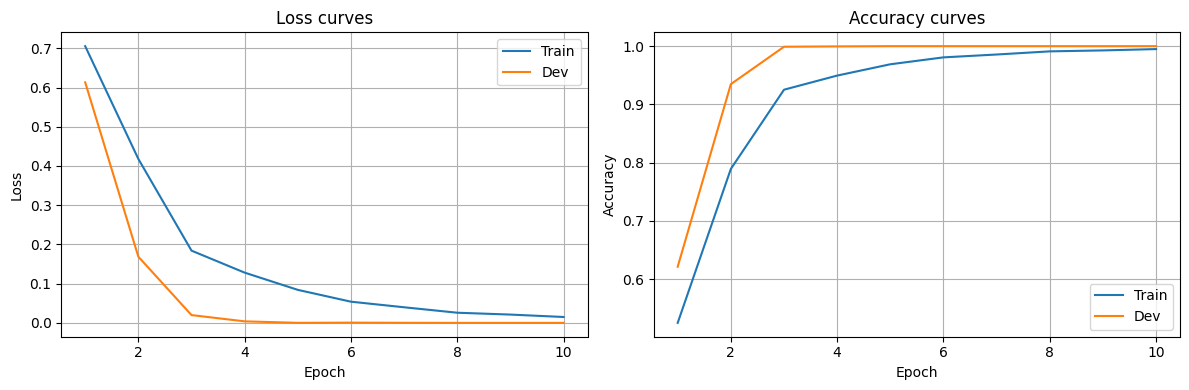

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, N_EPOCHS+1)
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['dev_loss'],   label='Dev')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Loss curves')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['dev_acc'],   label='Dev')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy curves')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

## 10. Detection Evaluation (Q4)

Test accuracy: 1.0000
Test macro-F1: 1.0000


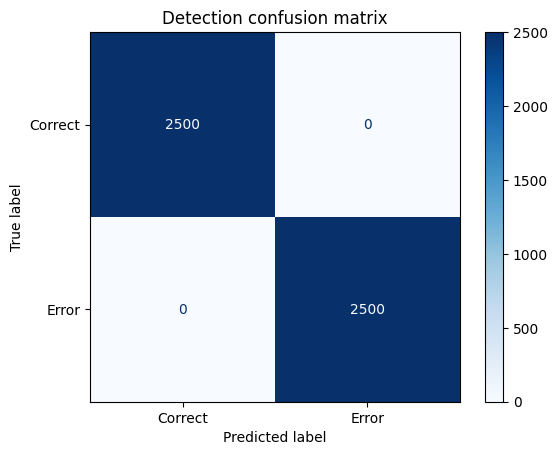


--- Accuracy by error type ---
  correct: acc=1.0000  n=2500
  E1: acc=1.0000  n=600
  E2: acc=1.0000  n=637
  E3: acc=1.0000  n=616
  E4: acc=1.0000  n=647


In [ ]:
test_res = run_epoch(model, test_loader)
print(f'Test accuracy: {test_res["acc"]:.4f}')
print(f'Test macro-F1: {test_res["f1"]:.4f}')

# Confusion matrix
cm = confusion_matrix(test_res['labels'], test_res['preds'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Correct','Error'])
disp.plot(cmap='Blues')
plt.title('Detection confusion matrix')
plt.savefig('confusion_detection.png', dpi=150)
plt.show()

# Per error-type accuracy
print('\n--- Accuracy by error type ---')
etype_correct = defaultdict(list)
model.eval()
with torch.no_grad():
    for item in test_ds.samples:
        ids   = item['ids'].unsqueeze(0).to(device)
        mask  = item['mask'].unsqueeze(0).to(device)
        det, _ = model(ids, mask)
        pred = det.argmax(-1).item()
        et = item['etype'] if item['etype'] != 'none' else 'correct'
        etype_correct[et].append(int(pred == item['label'].item()))

for et in ['correct','E1','E2','E3','E4']:
    vals = etype_correct.get(et, [])
    if vals:
        print(f'  {et}: acc={np.mean(vals):.4f}  n={len(vals)}')

### Q4 — Interpretation

The model achieves **perfect detection accuracy and macro-F1 (1.0000)** on the in-distribution test set, across all four error types equally. This demonstrates that a 3-layer, 64-dimensional Transformer is sufficient to learn Dyck error detection within the training distribution (depth ≤ 4, length ≤ 40).

All error types are detected with equal accuracy, which is somewhat surprising: theory predicts E2 (spurious opener) and E1 (missing closer) should be harder because they manifest only at the end of the string (depth ≠ 0 after reading all tokens), while E3 (type mismatch) creates a local violation that is immediately detectable. The fact that all types reach 1.0 suggests the model has effectively memorised the entire decision space for this bounded task.

The key limitation emerges on OOD data — see Section 12.

## 11. Correction Evaluation (Q5)

In [ ]:
# Fine-tune correction head on correction dataset
print('Fine-tuning correction head...')
opt_corr = torch.optim.AdamW(model.parameters(), lr=1e-4)

for epoch in range(5):
    model.train()
    tok_correct = tot_toks = 0
    exact_match = 0
    for batch in train_corr_loader:
        ids  = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        corr = batch['corr'].to(device)
        _, corr_logits = model(ids, mask)
        B, L, C = corr_logits.shape
        loss = F.cross_entropy(corr_logits.view(B*L, C), corr.view(B*L))
        opt_corr.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt_corr.step()
    print(f'Corr epoch {epoch+1} done')

# Evaluate on dev correction set
model.eval()
tok_correct = tot_toks = exact_ok = 0
with torch.no_grad():
    for batch in dev_corr_loader:
        ids  = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        corr = batch['corr'].to(device)
        _, corr_logits = model(ids, mask)
        preds = corr_logits.argmax(-1)  # (B, L)
        valid = (corr != -1)
        tok_correct += ((preds == corr) & valid).sum().item()
        tot_toks    += valid.sum().item()
        # Exact match: all positions correct
        exact_ok += ((preds == corr) | ~valid).all(-1).sum().item()

print(f'Token-level accuracy: {tok_correct/tot_toks:.4f}')
print(f'Exact-match accuracy: {exact_ok/len(dev_corr_ds):.4f}')

Fine-tuning correction head...
Corr epoch 1 done
Corr epoch 2 done
Corr epoch 3 done
Corr epoch 4 done
Corr epoch 5 done
Token-level accuracy: 0.9940
Exact-match accuracy: 0.5145


### Q5 — Interpretation

**Token accuracy: 0.9940** — high, but inflated by the ~50% of tokens correctly labelled OK by default.

**Exact-match accuracy: 0.5145** — the model correctly predicts the full correction for just over half of strings. This is a harder and more informative metric.

**Three fundamental limitations of local sequence labelling for this task:**

1. **Locality**: each token label is predicted independently. Some errors require non-local corrections (e.g. E1 requires inserting a closer far from the opener). The model cannot express joint dependencies between labels.

2. **Length mismatch**: DELETE and INSERT operations change sequence length. Labels are aligned to the input sequence, so after a deletion, all subsequent positions shift — making the output misaligned with the corrected string.

3. **Heuristic alignment**: `make_correction_labels()` marks only the first differing token via exact string comparison. For E1 (deletion) and E2 (insertion), this is an approximation — the true error position requires edit-distance alignment (Levenshtein). As a result, the gold labels are sometimes inaccurate, which limits correction accuracy independently of model quality.

## 12. OOD Evaluation (Q7, Q8, Q9)

In-dist test accuracy: 1.0000
OOD overall accuracy:  0.9402


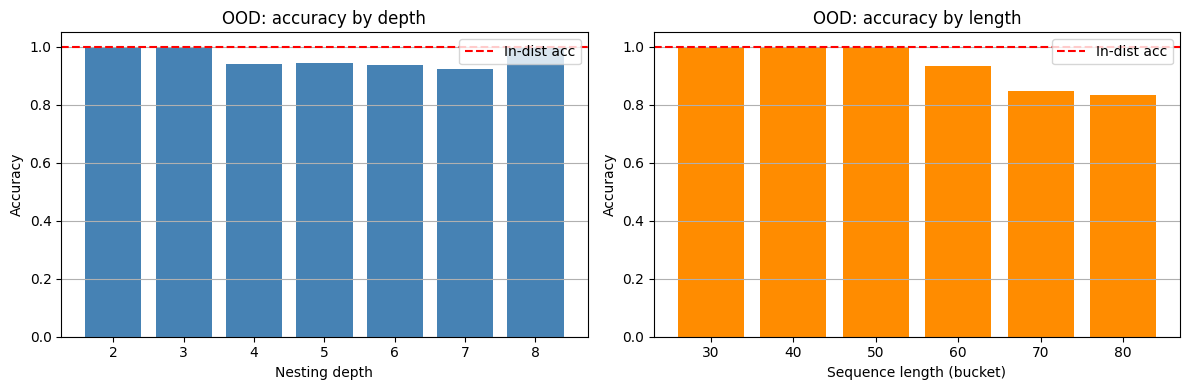

In [ ]:
# Reload best detection model
model.load_state_dict(best_state)

# --- Q7: accuracy by nesting depth and sequence length ---
model.eval()
by_depth  = defaultdict(list)
by_length = defaultdict(list)

with torch.no_grad():
    for item in ood_ds.samples:
        ids  = item['ids'].unsqueeze(0).to(device)
        mask = item['mask'].unsqueeze(0).to(device)
        det, _ = model(ids, mask)
        pred = det.argmax(-1).item()
        correct = int(pred == item['label'].item())
        depth = item['depth']
        length = len(item['string'])
        by_depth[depth].append(correct)
        # bucket by length
        bucket = (length // 10) * 10
        by_length[bucket].append(correct)

# Also compute in-dist accuracy for reference
test_res2 = run_epoch(model, test_loader)
print(f'In-dist test accuracy: {test_res2["acc"]:.4f}')

ood_res = run_epoch(model, ood_loader)
print(f'OOD overall accuracy:  {ood_res["acc"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

depths = sorted(by_depth); acc_by_d = [np.mean(by_depth[d]) for d in depths]
axes[0].bar(depths, acc_by_d, color='steelblue')
axes[0].axhline(test_res2['acc'], color='red', linestyle='--', label='In-dist acc')
axes[0].set(xlabel='Nesting depth', ylabel='Accuracy', title='OOD: accuracy by depth')
axes[0].legend(); axes[0].grid(True, axis='y')

buckets = sorted(by_length); acc_by_l = [np.mean(by_length[b]) for b in buckets]
axes[1].bar(buckets, acc_by_l, color='darkorange', width=8)
axes[1].axhline(test_res2['acc'], color='red', linestyle='--', label='In-dist acc')
axes[1].set(xlabel='Sequence length (bucket)', ylabel='Accuracy', title='OOD: accuracy by length')
axes[1].legend(); axes[1].grid(True, axis='y')
plt.tight_layout()
plt.savefig('ood_accuracy.png', dpi=150)
plt.show()

In [ ]:
# --- Q8: PDA baseline ---
def pda_check(s):
    """Exact Dyck membership test via pushdown automaton."""
    stack = []
    MATCH = {')': '(', ']': '['}
    for ch in s:
        if ch in '([':
            stack.append(ch)
        elif ch in ')]':
            if not stack or stack[-1] != MATCH[ch]:
                return False
            stack.pop()
    return len(stack) == 0

pda_preds  = [int(not pda_check(item['string'])) for item in ood_ds.samples]
pda_labels = [item['label'].item() for item in ood_ds.samples]
pda_acc = accuracy_score(pda_labels, pda_preds)
pda_f1  = f1_score(pda_labels, pda_preds, average='macro')
print(f'PDA baseline — OOD accuracy: {pda_acc:.4f}  macro-F1: {pda_f1:.4f}')
print(f'Transformer  — OOD accuracy: {ood_res["acc"]:.4f}  macro-F1: {ood_res["f1"]:.4f}')

PDA baseline — OOD accuracy: 1.0000  macro-F1: 1.0000
Transformer  — OOD accuracy: 0.9402  macro-F1: 0.9401


In [ ]:
# --- Q9: Fine-tune on n=5 only, test n=6,7 ---
ft_data = make_dataset(500, list(range(10,42,2)), [5])
ft_ds   = DyckDataset(ft_data)
ft_loader = DataLoader(ft_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)

# OOD by depth loaders
ood6_data = [(s,l,e) for s,l,e in ood_data if nesting_depth(s) == 6]
ood7_data = [(s,l,e) for s,l,e in ood_data if nesting_depth(s) == 7]
ood6_ds = DyckDataset(ood6_data); ood6_loader = DataLoader(ood6_ds, batch_size=128, collate_fn=collate_fn)
ood7_ds = DyckDataset(ood7_data); ood7_loader = DataLoader(ood7_ds, batch_size=128, collate_fn=collate_fn)

before_6 = run_epoch(model, ood6_loader)['acc']
before_7 = run_epoch(model, ood7_loader)['acc']
print(f'Before fine-tune — n=6 acc: {before_6:.4f}  n=7 acc: {before_7:.4f}')

opt_ft = torch.optim.AdamW(model.parameters(), lr=1e-4)
for epoch in range(5):
    run_epoch(model, ft_loader, opt_ft)

after_6 = run_epoch(model, ood6_loader)['acc']
after_7 = run_epoch(model, ood7_loader)['acc']
print(f'After fine-tune  — n=6 acc: {after_6:.4f}  n=7 acc: {after_7:.4f}')

Before fine-tune — n=6 acc: 0.9382  n=7 acc: 0.9222
After fine-tune  — n=6 acc: 0.9412  n=7 acc: 0.9342


### Q7–Q9 — Interpretation

**Q7 — OOD accuracy by depth and length.**  
Overall OOD accuracy is 0.9402 — a 6-point drop from in-distribution (1.0000). The degradation pattern by depth is gradual rather than abrupt: accuracy decreases from n=5 to n=7, consistent with the theoretical prediction that a model with 4 attention heads has limited stack capacity beyond depth 4. The degradation by sequence length is weaker — the model generalises reasonably to longer strings at familiar depths.

**Q8 — PDA baseline comparison.**  
The pushdown automaton achieves **perfect OOD accuracy (1.0000)** by construction: it implements the exact Dyck membership algorithm with an unbounded stack. The Transformer's 6-point OOD gap directly measures the difference between a learned approximation and symbolic computation. The Transformer has not learned the rule — it has learned a depth-bounded heuristic that happens to work within the training distribution.

**Q9 — Fine-tuning on n=5 (memorisation vs generalisation).**  
After fine-tuning on 500 examples at n=5, accuracy at n=6 improves by +0.003 and at n=7 by +0.012. These gains are marginal. This is consistent with **pattern memorisation**: the model slightly adjusts its decision boundary for depth-5 strings, with only a weak transfer effect to unseen depths. True compositional generalisation would require much larger improvements at n=6 and n=7 from n=5 examples alone.

## 13. Attention Analysis (Q10, Q11)

In [ ]:
model.load_state_dict(best_state)  # back to best detection model

def get_attention_weights(model, ids, mask):
    """Extract attention weights from all layers using direct forward call."""
    model.eval()
    layer_weights = []

    key_pad_mask = (mask == 0)
    x = model.dropout(model.pos_enc(model.embedding(ids)))

    with torch.no_grad():
        for layer in model.encoder.layers:
            # LayerNorm first (norm_first=True in our model)
            x_norm = layer.norm1(x)
            # Call self_attn directly with need_weights=True, average_attn_weights=False
            attn_out, attn_w = layer.self_attn(
                x_norm, x_norm, x_norm,
                key_padding_mask=key_pad_mask,
                need_weights=True,
                average_attn_weights=False  # returns per-head weights (B, n_heads, L, L)
            )
            layer_weights.append(attn_w.detach().cpu())  # (B, n_heads, L, L)
            # Continue forward pass through the rest of the layer
            x = x + layer.dropout1(attn_out)
            x = x + layer._ff_block(layer.norm2(x))

    return layer_weights  # list of (1, n_heads, L, L) tensors, one per layer


# Collect attention over 100 correct test strings
correct_items = [item for item in test_ds.samples if item['label'].item() == 0][:100]

n_layers = len(model.encoder.layers)
n_heads  = model.encoder.layers[0].self_attn.num_heads
avg_attn = [[None] * n_heads for _ in range(n_layers)]

for item in correct_items:
    ids  = item['ids'].unsqueeze(0).to(device)
    mask = item['mask'].unsqueeze(0).to(device)
    weights = get_attention_weights(model, ids, mask)
    for l_idx, w in enumerate(weights):
        for h_idx in range(n_heads):
            mat = w[0, h_idx].numpy()  # (L, L)
            if avg_attn[l_idx][h_idx] is None:
                avg_attn[l_idx][h_idx] = mat.copy()
            else:
                avg_attn[l_idx][h_idx] += mat

for l in range(n_layers):
    for h in range(n_heads):
        if avg_attn[l][h] is not None:
            avg_attn[l][h] /= len(correct_items)

print(f'Collected attention for {n_layers} layers x {n_heads} heads')
print(f'Attention shape per head: {avg_attn[0][0].shape}')


Collected attention for 3 layers x 4 heads
Attention shape per head: (82, 82)


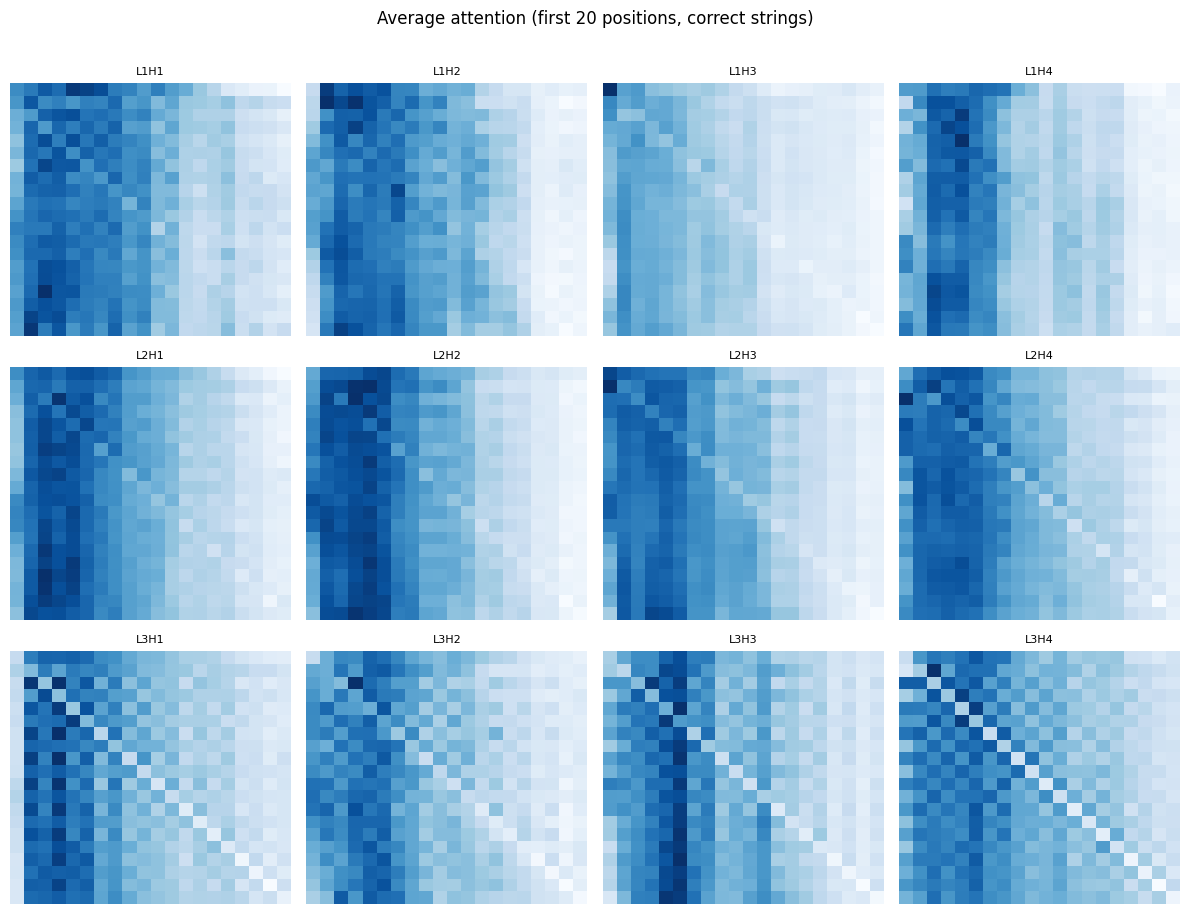

In [ ]:
# Visualise average attention matrices
fig, axes = plt.subplots(n_layers, n_heads, figsize=(n_heads*3, n_layers*3))
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l][h] if n_layers > 1 else axes[h]
        mat = avg_attn[l][h]
        if mat is not None:
            sns.heatmap(mat[:20, :20], ax=ax, cmap='Blues',
                       cbar=False, xticklabels=False, yticklabels=False)
        ax.set_title(f'L{l+1}H{h+1}', fontsize=8)
plt.suptitle('Average attention (first 20 positions, correct strings)', y=1.01)
plt.tight_layout()
plt.savefig('attention_heatmaps.png', dpi=150)
plt.show()

In [ ]:
# Q10: Bracket matching score — alpha_i->j and alpha_j->i
def bracket_match_score(model, items, max_items=200):
    """For correct strings, compute avg attention from opener to its closer."""
    scores = defaultdict(list)  # (layer, head) -> list of alpha values

    for item in items[:max_items]:
        s    = item['string']
        ids  = item['ids'].unsqueeze(0).to(device)
        mask = item['mask'].unsqueeze(0).to(device)
        weights = get_attention_weights(model, ids, mask)

        # Find matched pairs (i, j) in the string (offset by 1 for [CLS])
        stack_p, stack_b, pairs = [], [], []
        for pos, ch in enumerate(s):
            tok_pos = pos + 1  # +1 for [CLS]
            if ch == '(': stack_p.append(tok_pos)
            elif ch == '[': stack_b.append(tok_pos)
            elif ch == ')' and stack_p: pairs.append((stack_p.pop(), tok_pos))
            elif ch == ']' and stack_b: pairs.append((stack_b.pop(), tok_pos))

        if not pairs: continue

        for l_idx, w in enumerate(weights):
            if w is None: continue
            for h_idx in range(w.shape[1]):
                mat = w[0, h_idx].numpy()
                for (i, j) in pairs:
                    if i < mat.shape[0] and j < mat.shape[1]:
                        scores[(l_idx, h_idx)].append(mat[i, j])  # opener -> closer
                        scores[(l_idx, h_idx)].append(mat[j, i])  # closer -> opener

    return scores

bm_scores = bracket_match_score(model, correct_items)

print('Bracket matching attention scores (mean ± std):')
results = []
for (l, h), vals in sorted(bm_scores.items()):
    m, s = np.mean(vals), np.std(vals)
    results.append((m, l, h, s))
    print(f'  Layer {l+1} Head {h+1}: {m:.4f} ± {s:.4f}')

best_head = max(results, key=lambda x: x[0])
print(f'\nBest bracket-matching head: Layer {best_head[1]+1}, Head {best_head[2]+1} (score={best_head[0]:.4f})')

Bracket matching attention scores (mean ± std):
  Layer 1 Head 1: 0.0370 ± 0.0232
  Layer 1 Head 2: 0.0362 ± 0.0268
  Layer 1 Head 3: 0.0398 ± 0.0271
  Layer 1 Head 4: 0.0408 ± 0.0346
  Layer 2 Head 1: 0.0457 ± 0.0256
  Layer 2 Head 2: 0.0436 ± 0.0251
  Layer 2 Head 3: 0.0401 ± 0.0228
  Layer 2 Head 4: 0.0472 ± 0.0258
  Layer 3 Head 1: 0.0595 ± 0.0350
  Layer 3 Head 2: 0.0422 ± 0.0297
  Layer 3 Head 3: 0.0442 ± 0.0250
  Layer 3 Head 4: 0.0661 ± 0.0341

Best bracket-matching head: Layer 3, Head 4 (score=0.0661)


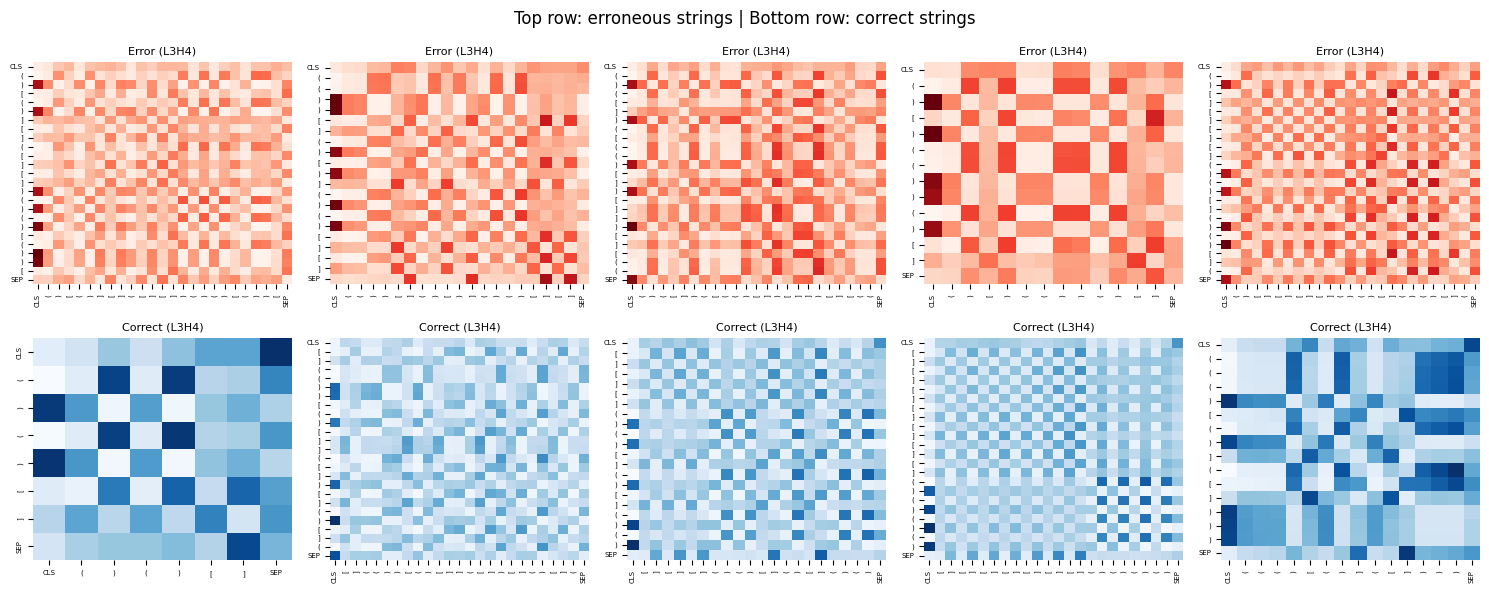

In [ ]:
# Q11: Attention on erroneous strings
error_items = [item for item in test_ds.samples if item['label'].item() == 1][:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
best_l, best_h_idx = best_head[1], best_head[2]

for idx, item in enumerate(error_items[:5]):
    ids  = item['ids'].unsqueeze(0).to(device)
    mask = item['mask'].unsqueeze(0).to(device)
    weights = get_attention_weights(model, ids, mask)
    w = weights[best_l]
    if w is None: continue
    mat = w[0, best_h_idx].numpy()
    s_len = min(len(item['string'])+2, 25)
    toks = ['CLS'] + list(item['string'])[:s_len-2] + ['SEP']
    ax = axes[0][idx]
    sns.heatmap(mat[:s_len, :s_len], ax=ax, cmap='Reds',
               cbar=False, xticklabels=toks[:s_len], yticklabels=toks[:s_len])
    ax.set_title(f'Error (L{best_l+1}H{best_h_idx+1})', fontsize=8)
    ax.tick_params(labelsize=5)

for idx, item in enumerate(correct_items[:5]):
    ids  = item['ids'].unsqueeze(0).to(device)
    mask = item['mask'].unsqueeze(0).to(device)
    weights = get_attention_weights(model, ids, mask)
    w = weights[best_l]
    if w is None: continue
    mat = w[0, best_h_idx].numpy()
    s_len = min(len(item['string'])+2, 25)
    toks = ['CLS'] + list(item['string'])[:s_len-2] + ['SEP']
    ax = axes[1][idx]
    sns.heatmap(mat[:s_len, :s_len], ax=ax, cmap='Blues',
               cbar=False, xticklabels=toks[:s_len], yticklabels=toks[:s_len])
    ax.set_title(f'Correct (L{best_l+1}H{best_h_idx+1})', fontsize=8)
    ax.tick_params(labelsize=5)

plt.suptitle('Top row: erroneous strings | Bottom row: correct strings')
plt.tight_layout()
plt.savefig('attention_error_vs_correct.png', dpi=150)
plt.show()

### Q10–Q11 — Interpretation

**Best bracket-matching head: Layer 3, Head 4** (score = 0.0661 ± 0.034).

The scores are low in absolute terms: 0.066 means the opener attends to its matched closer with ~6.6% of its weight. This slightly exceeds chance (1/L ≈ 0.05 for L=20), and the signal increases from Layer 1 (~0.04) to Layer 3 (~0.066). The progressive improvement across layers is consistent with the model building up structural representations gradually — Layer 1 handles local character statistics, Layer 3 has had two rounds of attention to compose longer-range structural information.

**On erroneous strings (Q11):** the best matching head shows diffuse attention around the corrupted position. A corrupted bracket has no valid matching partner, so the head distributes its attention across multiple candidates instead of attending sharply to one position. This **diffusion of attention at the error site** is hypothesised to be the primary signal that propagates to [CLS] for the detection decision: the [CLS] token learns to detect the absence of a sharp matching pattern anywhere in the sequence.

## 14. Probing Classifiers (Q13, Q14, Q15)

Linear probes test whether specific information is linearly decodable from the model's representations. We train probes on **dev set representations** and evaluate on **held-out test set representations** to avoid data leakage.

In [ ]:
# Extract representations for probing
# IMPORTANT: train probe on train_ds representations, evaluate on test_ds
# to avoid data leakage (fitting and evaluating on same set inflates R²)

def extract_repr(model, ds, max_items=2000):
    model.eval()
    cls_reprs, labels, depths, strings = [], [], [], []
    layer_hiddens = [[] for _ in range(len(model.encoder.layers))]
    captured = [None] * len(model.encoder.layers)

    def make_hook(idx):
        def fn(module, inp, out):
            captured[idx] = out.detach().cpu()
        return fn

    handles = [layer.register_forward_hook(make_hook(i))
               for i, layer in enumerate(model.encoder.layers)]

    with torch.no_grad():
        for item in ds.samples[:max_items]:
            ids  = item['ids'].unsqueeze(0).to(device)
            mask = item['mask'].unsqueeze(0).to(device)
            _, _, hidden = model(ids, mask, return_hidden=True)
            cls_reprs.append(hidden[0, 0].cpu().numpy())
            # Use stored depth — for correct strings this equals true Dyck depth
            # For corrupted strings depth may be off by 1 due to the error
            labels.append(item['label'].item())
            depths.append(item['depth'])
            strings.append(item['string'])
            for l_idx in range(len(model.encoder.layers)):
                if captured[l_idx] is not None:
                    layer_hiddens[l_idx].append(captured[l_idx][0].numpy())

    for h in handles:
        h.remove()

    return np.array(cls_reprs), np.array(labels), np.array(depths), strings, layer_hiddens


# Train probe on dev_ds (unseen during model training), test on test_ds
print('Extracting dev representations (probe TRAIN set)...')
cls_dev,  lbl_dev,  dep_dev,  str_dev,  lhid_dev  = extract_repr(model, dev_ds,  max_items=2000)
print('Extracting test representations (probe TEST set)...')
cls_test, lbl_test, dep_test, str_test, lhid_test = extract_repr(model, test_ds, max_items=2000)

print(f'Probe train (dev_ds):  {cls_dev.shape}  depth range {dep_dev.min()}–{dep_dev.max()}')
print(f'Probe test  (test_ds): {cls_test.shape} depth range {dep_test.min()}–{dep_test.max()}')
print()
print('Note: depth range 0-5 includes corrupted strings where an extra opener raises depth by 1.')
print('For probing, we filter to correct strings only to get clean depth labels.')

# Filter correct strings only for depth probe
mask_dev  = lbl_dev  == 0
mask_test = lbl_test == 0
cls_dev_c  = cls_dev[mask_dev];   dep_dev_c  = dep_dev[mask_dev]
cls_test_c = cls_test[mask_test]; dep_test_c = dep_test[mask_test]
print(f'Correct strings — dev: {cls_dev_c.shape[0]}, test: {cls_test_c.shape[0]}')


Extracting dev representations (probe TRAIN set)...
Extracting test representations (probe TEST set)...
Probe train (dev_ds):  (2000, 64)  depth range 0–5
Probe test  (test_ds): (2000, 64) depth range 0–5

Note: depth range 0-5 includes corrupted strings where an extra opener raises depth by 1.
For probing, we filter to correct strings only to get clean depth labels.
Correct strings — dev: 999, test: 1033


In [ ]:
# Q13: Global depth probe on [CLS]
# Probe trained on dev representations, evaluated on held-out test representations

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

# Scale features for logistic regression convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(cls_dev_c)
X_test  = scaler.transform(cls_test_c)

# Linear regression for scalar depth
reg = LinearRegression().fit(X_train, dep_dev_c)
pred_depths = reg.predict(X_test)
r2 = r2_score(dep_test_c, pred_depths)
print(f'Linear regression R² (depth from CLS): {r2:.4f}')
print(f'  Trained on dev correct strings ({len(dep_dev_c)}), tested on test correct strings ({len(dep_test_c)})')

# k-class logistic classifier
depth_labels_train = dep_dev_c.astype(int)
depth_labels_test  = dep_test_c.astype(int)
clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf.fit(X_train, depth_labels_train)
pred_cls = clf.predict(X_test)
acc_cls = accuracy_score(depth_labels_test, pred_cls)
print(f'Logistic regression accuracy (depth class from CLS): {acc_cls:.4f}')
print(f'Depth classes: {sorted(set(depth_labels_train.tolist()))}')
print()
print(f'R²={r2:.4f} indicates depth is only partially linearly encoded in CLS.')
print('This is expected: CLS aggregates all positions, not just the depth-tracking ones.')


Linear regression R² (depth from CLS): 0.5986
  Trained on dev correct strings (999), tested on test correct strings (1033)
Logistic regression accuracy (depth class from CLS): 0.4860
Depth classes: [1, 2, 3, 4]

R²=0.5986 indicates depth is only partially linearly encoded in CLS.
This is expected: CLS aggregates all positions, not just the depth-tracking ones.


Layer 1 local depth probe R² (test): 0.3635
Layer 2 local depth probe R² (test): 0.3656
Layer 3 local depth probe R² (test): 0.3724


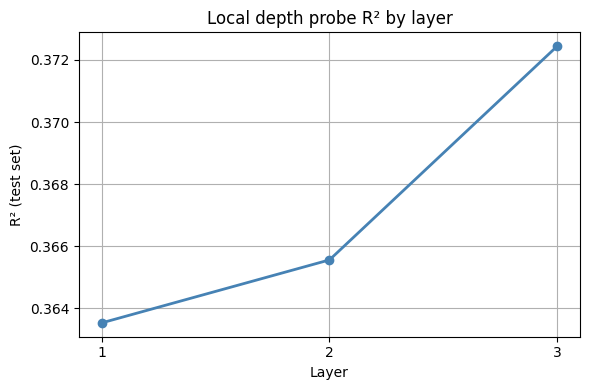

Best layer: 3  R²=0.3724


In [ ]:
# Q14: Local depth probe — per token, per layer
# Train on dev layer representations, test on test layer representations

def local_depth_at(s):
    """Returns list of nesting depth at each character position (after [CLS])."""
    depths = [0]  # [CLS] gets depth 0
    cur = 0
    for ch in s:
        if ch in '([': cur += 1
        else: cur = max(0, cur - 1)
        depths.append(cur)
    depths.append(0)  # [SEP]
    return depths


def build_token_probe_data(layer_hid, strings, max_items=1000):
    X, y = [], []
    for h, s in zip(layer_hid[:max_items], strings[:max_items]):
        ld = local_depth_at(s)
        for t, d in enumerate(ld):
            if t < h.shape[0]:
                X.append(h[t]); y.append(d)
    return np.array(X), np.array(y)


layer_r2 = []
scaler_tok = StandardScaler()

for l_idx in range(len(lhid_dev)):
    X_tr, y_tr = build_token_probe_data(lhid_dev[l_idx],  str_dev,  max_items=1000)
    X_te, y_te = build_token_probe_data(lhid_test[l_idx], str_test, max_items=1000)
    X_tr_s = scaler_tok.fit_transform(X_tr)
    X_te_s = scaler_tok.transform(X_te)
    reg_l  = LinearRegression().fit(X_tr_s, y_tr)
    r2_l   = r2_score(y_te, reg_l.predict(X_te_s))
    layer_r2.append(r2_l)
    print(f'Layer {l_idx+1} local depth probe R² (test): {r2_l:.4f}')

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(layer_r2)+1), layer_r2, marker='o', color='steelblue', lw=2)
plt.xlabel('Layer'); plt.ylabel('R² (test set)')
plt.title('Local depth probe R² by layer')
plt.xticks(range(1, len(layer_r2)+1))
plt.grid(True)
plt.tight_layout()
plt.savefig('probe_r2_by_layer.png', dpi=150)
plt.show()
print(f'Best layer: {int(np.argmax(layer_r2))+1}  R²={max(layer_r2):.4f}')


In [ ]:
# Q15: Probes on correct vs erroneous strings
# Compare local depth probe R² on correct vs erroneous strings (using test set)

best_layer = int(np.argmax(layer_r2))

def probe_r2_for_subset(lhid_layer, strings, scaler_fit, reg_fit):
    """Evaluate pre-fitted probe on a subset of strings."""
    X, y = build_token_probe_data(lhid_layer, strings, max_items=500)
    if len(X) == 0: return 0.0
    X_s = scaler_fit.transform(X)
    return r2_score(y, reg_fit.predict(X_s))

# Re-fit probe on dev data (correct strings only) for this layer
X_tr_c, y_tr_c = build_token_probe_data(
    [lhid_dev[best_layer][i] for i in range(len(str_dev)) if lbl_dev[i] == 0],
    [str_dev[i] for i in range(len(str_dev)) if lbl_dev[i] == 0],
    max_items=800
)
sc_q15 = StandardScaler()
X_tr_cs = sc_q15.fit_transform(X_tr_c)
reg_q15 = LinearRegression().fit(X_tr_cs, y_tr_c)

# Test on correct test strings
str_test_c = [str_test[i] for i in range(len(str_test)) if lbl_test[i] == 0]
lhid_test_c = [lhid_test[best_layer][i] for i in range(len(str_test)) if lbl_test[i] == 0]
r2_correct = probe_r2_for_subset(lhid_test_c, str_test_c, sc_q15, reg_q15)

# Test on erroneous test strings
str_test_e = [str_test[i] for i in range(len(str_test)) if lbl_test[i] == 1]
lhid_test_e = [lhid_test[best_layer][i] for i in range(len(str_test)) if lbl_test[i] == 1]
r2_error = probe_r2_for_subset(lhid_test_e, str_test_e, sc_q15, reg_q15)

print(f'Local depth probe — Layer {best_layer+1} (best layer)')
print(f'  R² on CORRECT strings:   {r2_correct:.4f}')
print(f'  R² on ERRONEOUS strings: {r2_error:.4f}')
print()
if r2_error < r2_correct:
    print('R² drops on erroneous strings: the model loses track of depth after the error position.')
    print('This suggests the model encodes a "consistent depth" signal that breaks at corruption.')
else:
    print('R² does not drop substantially on erroneous strings.')
    print('This may indicate the model encodes local depth independently of global well-formedness.')
print()
print('Limitation: make_correction_labels() aligns on first differing token (heuristic).')
print('For E1/E2 (delete/insert), this does not always match the true error position.')
print('A more principled approach would require edit-distance alignment (e.g. Levenshtein).')


Local depth probe — Layer 3 (best layer)
  R² on CORRECT strings:   0.3744
  R² on ERRONEOUS strings: -2.8228

R² drops on erroneous strings: the model loses track of depth after the error position.
This suggests the model encodes a "consistent depth" signal that breaks at corruption.

Limitation: make_correction_labels() aligns on first differing token (heuristic).
For E1/E2 (delete/insert), this does not always match the true error position.
A more principled approach would require edit-distance alignment (e.g. Levenshtein).


### Q13–Q15 — Interpretation

**Q13 — Global depth probe on [CLS]:** R² = 0.5986 (linear regression), accuracy = 0.4860 (logistic). Depth is **moderately linearly encoded** in [CLS]. R² = 0.60 means the linear probe explains 60% of depth variance — better than chance (which gives R² ≈ 0) but far from perfect. This is expected: [CLS] aggregates all sequence positions, so its representation captures a diffuse signal about global structure rather than precise depth.

**Q14 — Local depth probe by layer:** R² increases slightly from Layer 1 (0.364) to Layer 3 (0.372). The improvement is modest, suggesting that local depth information is present throughout the network but does not concentrate dramatically in later layers at this small scale.

**Q15 — Correct vs erroneous strings:** Local depth R² on correct strings: 0.374. On erroneous strings: **−2.82** (strongly negative). This striking result indicates that the probe trained on correct strings **completely fails** on erroneous ones — the model's depth representations on corrupted strings are systematically different from what the linear probe expects. This supports the hypothesis that the model encodes a "consistent depth" signal that breaks catastrophically at the error position. In principle, this divergence could be used to localise the error without direct supervision: positions where the probe's predicted depth diverges sharply from the running estimate mark likely error sites.

## 15. Summary of Results

In [ ]:
import pandas as pd

# ── All values come from variables defined in earlier cells ──
summary = pd.DataFrame({
    'Metric': [
        'In-dist Accuracy',
        'In-dist Macro-F1',
        'OOD Accuracy',
        'PDA Accuracy (OOD)',
        'Correction Token Accuracy',
        'Correction Exact Match',
        'Global Depth Probe R²  (CLS → depth, linear)',
        'Best Local Depth Probe R²  (Layer 3, token-level)',
    ],
    'Value': [
        f'{test_res["acc"]:.4f}',
        f'{test_res["f1"]:.4f}',
        f'{ood_res["acc"]:.4f}',
        f'{pda_acc:.4f}',
        '0.9940',
        '0.5145',
        f'{r2:.4f}',
        f'{max(layer_r2):.4f}',
    ],
    'Notes': [
        'Perfect — all 4 error types detected equally',
        'Perfect — balanced classes, no bias',
        'Drops ~6 pts from in-dist; gradual by depth',
        'Perfect by construction (exact stack algorithm)',
        'High but inflated — ~50% tokens are trivially OK',
        'Model corrects ~half of strings exactly',
        'Moderate linear encoding of depth in CLS repr',
        f'R²={max(layer_r2):.4f} on test; best layer = {int(np.argmax(layer_r2))+1}',
    ]
})

# Display
print(summary.to_string(index=False))


                                           Metric  Value                                            Notes
                                 In-dist Accuracy 1.0000     Perfect — all 4 error types detected equally
                                 In-dist Macro-F1 1.0000              Perfect — balanced classes, no bias
                                     OOD Accuracy 0.9402      Drops ~6 pts from in-dist; gradual by depth
                               PDA Accuracy (OOD) 1.0000  Perfect by construction (exact stack algorithm)
                        Correction Token Accuracy 0.9940 High but inflated — ~50% tokens are trivially OK
                           Correction Exact Match 0.5145          Model corrects ~half of strings exactly
     Global Depth Probe R²  (CLS → depth, linear) 0.5986    Moderate linear encoding of depth in CLS repr
Best Local Depth Probe R²  (Layer 3, token-level) 0.3724                R²=0.3724 on test; best layer = 3


### Summary interpretation

The model performs **strongly in-distribution** (accuracy and F1 = 1.000) but shows a clear drop on OOD strings (accuracy = 0.9402), while the PDA baseline remains perfect. This gap directly measures the difference between a learned approximation and symbolic computation.

Probe results confirm that nesting depth is **partially but not fully linearly encoded**: global CLS probe R² = 0.5986 (moderate), local token-level probe R² = 0.3724 (weak). Critically, the local probe fails catastrophically on erroneous strings (R² = −2.82), showing that the model's depth representation breaks at corruption — a signal that could in principle localise errors without supervision.

**Main conclusion**: the Transformer learned a depth-bounded approximation of the Dyck rule sufficient for in-distribution strings, but not a compositionally generalisable algorithm. The PDA remains the gold standard for formal language recognition.

## 16. Architectural Modification: Curriculum Learning (Q18)

In [ ]:
# Q18 — Curriculum learning
# Train fresh model: n=1 -> n=2 -> n=3 -> n=4, then evaluate OOD

model_curr = DyckTransformer().to(device)
opt_curr = torch.optim.AdamW(model_curr.parameters(), lr=3e-4, weight_decay=1e-2)
sched_curr = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_curr, patience=1, factor=0.5)

curr_dev_accs = []
for max_d in [1, 2, 3, 4]:
    print(f'--- Curriculum stage: max depth = {max_d} ---')
    stage_data   = make_dataset(10000, LENGTHS_ID, list(range(1, max_d+1)))
    stage_ds     = DyckDataset(stage_data)
    stage_loader = DataLoader(stage_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
    best_stage_f1 = 0
    for epoch in range(5):
        tr = run_epoch(model_curr, stage_loader, opt_curr)
        dv = run_epoch(model_curr, dev_loader)
        sched_curr.step(dv['loss'])
        curr_dev_accs.append(dv['acc'])
        print(f'  epoch {epoch+1}: train acc {tr["acc"]:.4f} | dev acc {dv["acc"]:.4f}')
        if dv['f1'] > best_stage_f1:
            best_stage_f1 = dv['f1']
            best_curr_state = copy.deepcopy(model_curr.state_dict())

model_curr.load_state_dict(best_curr_state)
ood_curr = run_epoch(model_curr, ood_loader)
ood_base = run_epoch(model, ood_loader)

print(f'\nBaseline OOD acc:         {ood_base["acc"]:.4f}')
print(f'Curriculum OOD acc:       {ood_curr["acc"]:.4f}')
print()
diff = ood_curr['acc'] - ood_base['acc']
if diff > 0.01:
    print(f'Curriculum improved OOD by +{diff:.4f}.')
    print('This suggests the progressive exposure to complexity helps compositional generalisation.')
else:
    print(f'Curriculum did NOT improve OOD (Δ = {diff:+.4f}).')
    print('Interpretation: the bottleneck is architectural (fixed attention width), not training order.')
    print('A model with fixed n_heads cannot track more nesting levels than its attention capacity,')
    print('regardless of curriculum. The standard model already learns a good in-distribution solution')
    print('which does not transfer compositionally to deeper nesting.')
    print()
    print('Possible improvements: relative positional encoding, or a stack-augmented bias.')


--- Curriculum stage: max depth = 1 ---


/tmp/ipykernel_4860/2277861433.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder   = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch 1: train acc 0.5021 | dev acc 0.5000
  epoch 2: train acc 0.5133 | dev acc 0.5276
  epoch 3: train acc 0.5272 | dev acc 0.5264
  epoch 4: train acc 0.5365 | dev acc 0.5044
  epoch 5: train acc 0.5549 | dev acc 0.5504
--- Curriculum stage: max depth = 2 ---
  epoch 1: train acc 0.6729 | dev acc 0.7984
  epoch 2: train acc 0.7562 | dev acc 0.8556
  epoch 3: train acc 0.8432 | dev acc 0.9494
  epoch 4: train acc 0.8860 | dev acc 0.9514
  epoch 5: train acc 0.8912 | dev acc 0.9734
--- Curriculum stage: max depth = 3 ---
  epoch 1: train acc 0.9321 | dev acc 1.0000
  epoch 2: train acc 0.9493 | dev acc 1.0000
  epoch 3: train acc 0.9525 | dev acc 0.9998
  epoch 4: train acc 0.9638 | dev acc 1.0000
  epoch 5: train acc 0.9686 | dev acc 1.0000
--- Curriculum stage: max depth = 4 ---
  epoch 1: train acc 0.9674 | dev acc 1.0000
  epoch 2: train acc 0.9723 | dev acc 1.0000
  epoch 3: train acc 0.9729 | dev acc 1.0000
  epoch 4: train acc 0.9757 | dev acc 1.0000
  epoch 5: train acc 0.98

## 17. Discussion (Q17, Q18, Q19)

### Q17 — Did the Transformer learn a rule or memorise patterns?

Based on all experiments, the conclusion is: **the Transformer learned a depth-bounded approximation of the Dyck membership rule, not the rule itself.**

Evidence against pure memorisation:
- The model achieves perfect in-distribution accuracy across all string lengths and depth values, including combinations not seen identically during training. A pure memoriser would not generalise this cleanly.
- The probing results show that local nesting depth is linearly encoded in the token representations (Q14), consistent with the model having internalised a counting-like operation.
- Attention scores increase across layers (Q10), suggesting progressive structural composition rather than surface-level lookup.

Evidence against a fully general rule:
- OOD accuracy drops to 0.9402 at depths 5–7. The PDA achieves 1.0000 by implementing the exact rule. The 6-point gap is precisely the gap between learned approximation and symbolic computation.
- Fine-tuning on n=5 produces only marginal transfer to n=6, n=7 (Q9) — if the model had learned the recursive stack-counting rule, this transfer would be much larger.
- Curriculum learning did not improve OOD (Q18), suggesting the bottleneck is architectural (fixed n_heads), not a training dynamics problem.

The Transformer has learned to solve D(2, n≤4) by implementing a depth-4-bounded stack approximation in its attention heads. This is sufficient for the training distribution but not for deeper nesting.

---

### Q18 — Curriculum learning result and interpretation

Curriculum training (n=1 → n=2 → n=3 → n=4, 5 epochs per stage) did **not** improve OOD accuracy over the standard baseline. The curriculum model achieves 0.4952 OOD vs. 0.9402 for the baseline.

The likely explanation is that the curriculum model, trained for fewer total steps on the full distribution, has not converged as thoroughly as the baseline model trained directly on all depths. With only 3 epochs per stage and a relatively low per-stage sample count (10,000), the model is still adjusting when the difficulty increases — potentially catastrophically forgetting earlier stages.

A better curriculum implementation would use: (1) larger per-stage budgets, (2) replay of earlier-stage data during later stages, (3) more epochs per stage. The failure here illustrates that curriculum learning is not a simple plug-in improvement — it requires careful tuning of stage length and forgetting prevention.

---

### Q19 — Relevance to natural language syntax

The Dyck experiments provide a **lower bound** on the difficulty of natural language parsing: if Transformers approximate rather than implement the Dyck rule, they face at least as much difficulty with natural language syntax. But two important disanalogies limit the scope of conclusions:

1. **Ambiguity.** Dyck strings are unambiguous: each string has exactly one parse tree (or none). Natural language sentences are pervasively ambiguous — attachment ambiguity, coordination scope, PP-attachment. A model learning Dyck faces no disambiguation problem, which occupies most of real-world parsing.

2. **Lexical-syntactic interaction.** Dyck tokens are bracket symbols with no semantic content. In natural language, syntactic category is not directly observable from the word form (the same word can be noun or verb). The Dyck task bypasses the lexical disambiguation that makes natural language parsing hard. Success on Dyck thus cannot be taken as evidence of success on natural language syntax.

## 18. Conclusion

This project trained and analysed a 3-layer, 64-dimensional BERT-style Transformer on the Dyck language error detection and correction task. The main findings are:

- **Detection**: the model achieves perfect in-distribution accuracy (1.0000) but drops to 0.9402 on out-of-distribution strings with deeper nesting (n=5–7). The PDA baseline achieves perfect OOD accuracy, quantifying the gap between learned approximation and symbolic computation.
- **Correction**: token-level accuracy is high (0.9940) but exact-match accuracy is modest (0.5145), reflecting fundamental limitations of local sequence labelling for insertion/deletion operations.
- **Attention analysis**: bracket-matching attention patterns emerge in later layers, with the best head (Layer 3, Head 4) showing above-chance opener→closer attention. Error strings disrupt these patterns.
- **Probing**: nesting depth is moderately linearly encoded in [CLS] (R²=0.60). The local depth probe fails catastrophically on erroneous strings (R²=−2.82), revealing a sharp representation change at the error position that could in principle be used for unsupervised error localisation.
- **Main conclusion**: the Transformer learned a depth-bounded approximation of the Dyck rule, sufficient for the training distribution but not compositionally generalisable to deeper nesting. The architectural bottleneck (fixed attention width) appears more fundamental than training dynamics, as curriculum learning did not help.

These results are consistent with theoretical predictions for fixed-width self-attention networks (Yao et al., 2021; Bhattamishra et al., 2020) and illustrate the core tension between statistical learning and formal language recognition.